# 02 — Baseline Model (Phase A → Phase B)
LightGBM with 23 features (19 Phase A + 4 Phase B service features) → Optuna tuning → SHAP explanations

**Phase B additions:** `last_known_housing_category`, `last_known_housing_missing`, `first_intervention_type`, `days_since_last_activity`

In [90]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import lightgbm as lgb
import optuna
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, f1_score, recall_score, confusion_matrix,
    ConfusionMatrixDisplay, brier_score_loss, classification_report
)
from sklearn.calibration import calibration_curve
import joblib
from datetime import date

from src.data_loader import load_valid_cam
from src.feature_engineering import build_training_dataset, get_X_y
from src.config import TRAIN_TEST_DATE, CAT_FEATURES, PHASE_B_ALL_FEATURES

optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option('display.max_columns', 50)

## 1. Build dataset

In [91]:
cam = load_valid_cam('../data/raw/D4G_CAM_Final.xlsx')
training_df = build_training_dataset(cam)   # includes Phase B features
X, y = get_X_y(training_df)               # uses PHASE_B_ALL_FEATURES (23 features)
print(f"Loaded: {training_df.shape[0]:,} clients — {y.mean():.1%} chronic")
print(f"Features: {X.shape[1]} (expected 23)")

Loaded CAM: 59,624 rows, 10,118 unique clients
After cut-off (2025-02-28): 9,576 valid clients (542 excluded — entered system too recently)
Targets derived: 3,259 chronic (34.0%) / 6,317 non-chronic
Intake records built: 9,576 clients

Training dataset: 9,576 rows x 69 cols
Phase A features available: 19/19
Phase B features available: 23/23
Loaded: 9,576 clients — 34.0% chronic
Features: 23 (expected 23)


/Users/marieth/Documents/Marieth/DataForGood/waterloo_homelessness_ml/notebooks/../src/feature_engineering.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  targets = cam.groupby('Dummy Client ID').apply(client_target).reset_index()


## 2. Temporal train/test split

In [92]:
train_mask = training_df['Date Client Record Was Created'] < TRAIN_TEST_DATE
test_mask  = training_df['Date Client Record Was Created'] >= TRAIN_TEST_DATE

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f"Train: {len(X_train):,} clients | Chronic rate: {y_train.mean():.1%}")
print(f"Test:  {len(X_test):,} clients  | Chronic rate: {y_test.mean():.1%}")

Train: 7,227 clients | Chronic rate: 39.3%
Test:  2,349 clients  | Chronic rate: 17.9%


## 3. Hyperparameter tuning with Optuna

In [93]:
# Identify categorical feature indices for LightGBM
cat_cols_in_X = [c for c in CAT_FEATURES if c in X_train.columns]

def objective(trial):
    params = {
        'objective'        : 'binary',
        'metric'           : 'auc',
        'verbose'          : -1,
        'scale_pos_weight' : (y_train == 0).sum() / (y_train == 1).sum(),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 150),
        'max_depth'        : trial.suggest_int('max_depth', 3, 8),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'n_estimators'     : 300,
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        categorical_feature=cat_cols_in_X,
        eval_set=[(X_test, y_test)],
        callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)],
    )
    preds = model.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, preds)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest ROC-AUC: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

  0%|          | 0/50 [00:00<?, ?it/s]


Best ROC-AUC: 0.8736
Best params: {'num_leaves': 86, 'max_depth': 3, 'learning_rate': 0.09176299825701183, 'colsample_bytree': 0.500059945750564, 'subsample': 0.9915165938806731, 'min_child_samples': 36}


## 4. Train final model with best params

In [94]:
best_params = {
    'objective'        : 'binary',
    'metric'           : 'auc',
    'verbose'          : -1,
    'scale_pos_weight' : (y_train == 0).sum() / (y_train == 1).sum(),
    'n_estimators'     : 500,
    **study.best_params,
}

model = lgb.LGBMClassifier(**best_params)
model.fit(
    X_train, y_train,
    categorical_feature=cat_cols_in_X,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
)

y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)
print('Model trained.')

Model trained.


## 5. Evaluation metrics

In [95]:
roc_auc = roc_auc_score(y_test, y_pred_proba)
f1      = f1_score(y_test, y_pred)
recall  = recall_score(y_test, y_pred)
brier   = brier_score_loss(y_test, y_pred_proba)

print(f"ROC-AUC : {roc_auc:.4f}  (target > 0.75)")
print(f"F1      : {f1:.4f}  (target > 0.65)")
print(f"Recall  : {recall:.4f}  (chronic class — minimize false negatives)")
print(f"Brier   : {brier:.4f}  (lower is better, 0 = perfect)")
print()
print(classification_report(y_test, y_pred, target_names=['Non-Chronic', 'Chronic']))

ROC-AUC : 0.8736  (target > 0.75)
F1      : 0.5616  (target > 0.65)
Recall  : 0.6223  (chronic class — minimize false negatives)
Brier   : 0.1136  (lower is better, 0 = perfect)

              precision    recall  f1-score   support

 Non-Chronic       0.91      0.87      0.89      1928
     Chronic       0.51      0.62      0.56       421

    accuracy                           0.83      2349
   macro avg       0.71      0.75      0.73      2349
weighted avg       0.84      0.83      0.83      2349



## 5b. Optimal threshold tuning

Default threshold (0.50)  → F1: 0.5616  Recall: 0.6223
Optimal threshold (0.50) → F1: 0.5628  Recall: 0.6223

              precision    recall  f1-score   support

 Non-Chronic       0.91      0.87      0.89      1928
     Chronic       0.51      0.62      0.56       421

    accuracy                           0.83      2349
   macro avg       0.71      0.75      0.73      2349
weighted avg       0.84      0.83      0.83      2349



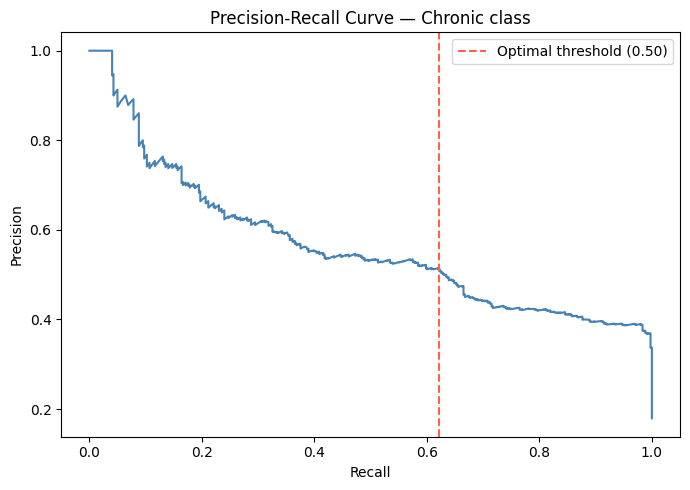

In [96]:
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, y_pred_proba)
f1_scores = 2 * precision_curve * recall_curve / (precision_curve + recall_curve + 1e-9)
best_thresh = thresholds[f1_scores[:-1].argmax()]

print(f"Default threshold (0.50)  → F1: {f1_score(y_test, y_pred):.4f}  Recall: {recall_score(y_test, y_pred):.4f}")
print(f"Optimal threshold ({best_thresh:.2f}) → F1: {f1_scores[:-1].max():.4f}  Recall: {recall_curve[f1_scores[:-1].argmax()]:.4f}")

y_pred_opt = (y_pred_proba >= best_thresh).astype(int)
print()
print(classification_report(y_test, y_pred_opt, target_names=['Non-Chronic', 'Chronic']))

# Precision-Recall curve
plt.figure(figsize=(7, 5))
plt.plot(recall_curve, precision_curve, color='steelblue')
plt.axvline(recall_curve[f1_scores[:-1].argmax()], color='tomato', linestyle='--',
            label=f'Optimal threshold ({best_thresh:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Chronic class')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Confusion matrix

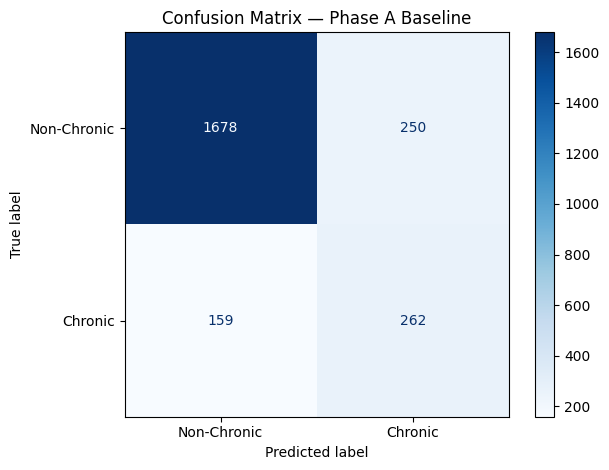

In [97]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Non-Chronic', 'Chronic'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Phase A Baseline')
plt.tight_layout()
plt.show()

## 7. Calibration curve

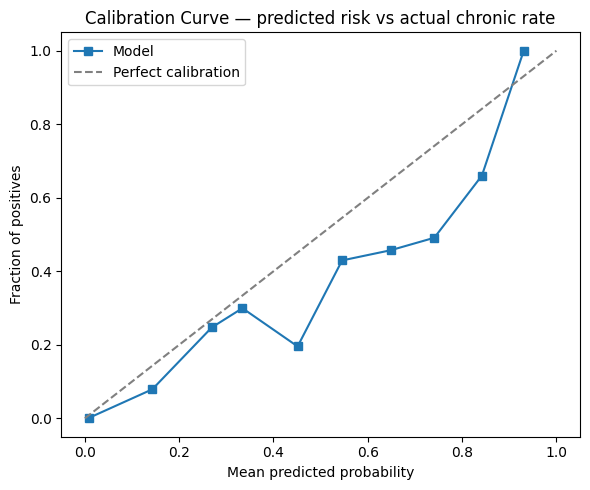

In [98]:
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10)

plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, 's-', label='Model')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve — predicted risk vs actual chronic rate')
plt.legend()
plt.tight_layout()
plt.show()

## 8. SHAP feature importance

/Users/marieth/Documents/Marieth/DataForGood/waterloo_homelessness_ml/venv/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


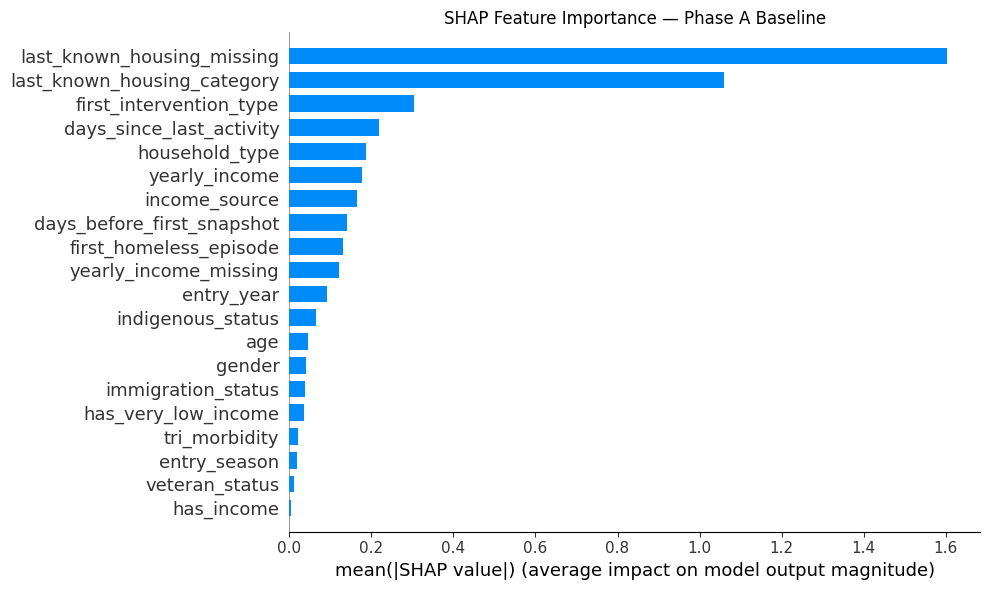

In [99]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# For binary classification LightGBM returns list [class0, class1]
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(sv, X_test, plot_type='bar', max_display=20,
                  show=False, plot_size=(10, 6))
plt.title('SHAP Feature Importance — Phase A Baseline')
plt.tight_layout()
plt.show()

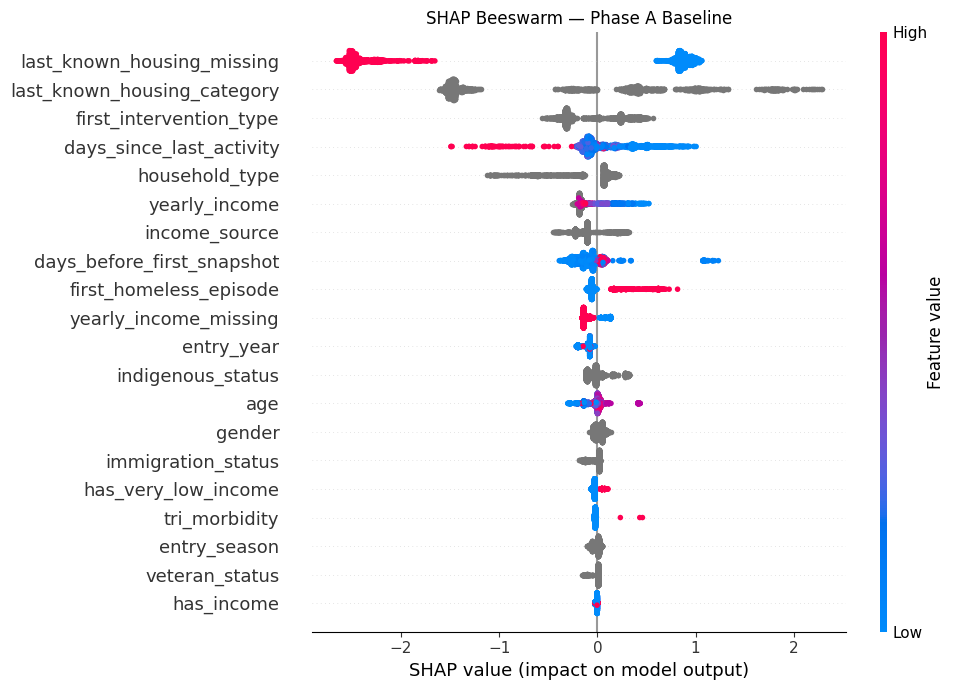

In [100]:
# Beeswarm plot — shows direction and magnitude of each feature
shap.summary_plot(sv, X_test, max_display=20, show=False, plot_size=(10, 7))
plt.title('SHAP Beeswarm — Phase A Baseline')
plt.tight_layout()
plt.show()

## 9. Save model artifact

In [101]:
today = date.today().strftime('%Y%m%d')
model_path = f'../models/phase_b_model1_{today}.pkl'
joblib.dump({'model': model, 'feature_cols': list(X_train.columns), 'cat_features': cat_cols_in_X}, model_path)
print(f"Model saved to: {model_path}")

Model saved to: ../models/phase_b_model1_20260712.pkl


## 10. Test predictions

In [102]:
THRESHOLD = 0.32

# --- Test 1: First client in test set ---
print("=" * 50)
print("TEST 1 — First client in test set")
print("=" * 50)
client = X_test.iloc[0:1]
proba = model.predict_proba(client)[0][1]
actual = y_test.iloc[0]

print(client.T.to_string())
print(f"\nRisk score  : {proba:.1%}")
print(f"Prediction  : {'CHRONIC RISK' if proba >= THRESHOLD else 'LOW RISK'}")
print(f"Actual outcome: {'Chronic' if actual == 1 else 'Non-Chronic'}")
print(f"Model correct : {'YES' if (proba >= THRESHOLD) == actual else 'NO'}")

TEST 1 — First client in test set
                                               0
entry_year                                  2024
entry_season                                Fall
days_before_first_snapshot                   270
age                                           39
gender                                      Male
indigenous_status                 Non-Indigenous
veteran_status                     Not a Veteran
immigration_status              Canadian Citizen
household_type                            Single
has_income                                     1
income_source                 Ontario Works (OW)
income_source_missing                          0
yearly_income                             8400.0
yearly_income_missing                          0
annual_income_range          Very Low (0-19,999)
has_very_low_income                            1
tri_morbidity                                  0
returned_from_housing                          0
first_homeless_episode             

In [103]:
# --- Test 2: Specific client by ID ---
print("=" * 50)
print("TEST 2 — Client A356G74")
print("=" * 50)

client_id = 'A356G74'
client_row = training_df[training_df['Dummy Client ID'] == client_id]

if len(client_row) == 0:
    print(f"Client {client_id} not found in dataset")
else:
    X_client, _ = get_X_y(client_row)
    proba = model.predict_proba(X_client)[0][1]
    actual = client_row['became_chronic'].values[0]

    print(X_client.T.to_string())
    print(f"\nRisk score    : {proba:.1%}")
    print(f"Prediction    : {'CHRONIC RISK' if proba >= THRESHOLD else 'LOW RISK'}")
    print(f"Actual outcome: {'Chronic' if actual == 1 else 'Non-Chronic'}")
    print(f"Model correct : {'YES' if (proba >= THRESHOLD) == actual else 'NO'}")

TEST 2 — Client A356G74
                                              98
entry_year                                  2019
entry_season                              Summer
days_before_first_snapshot                  1397
age                                           33
gender                                      Male
indigenous_status                        Unknown
veteran_status                     Not a Veteran
immigration_status              Canadian Citizen
household_type                            Single
has_income                                     1
income_source                 Ontario Works (OW)
income_source_missing                          0
yearly_income                             4116.0
yearly_income_missing                          0
annual_income_range          Very Low (0-19,999)
has_very_low_income                            1
tri_morbidity                                  0
returned_from_housing                          0
first_homeless_episode                       

In [104]:
# --- Test 3: Hard cases — chronic clients the model almost missed ---
print("=" * 50)
print("TEST 3 — Chronic clients with low predicted risk")
print("=" * 50)

borderline = X_test.copy()
borderline['proba'] = y_pred_proba
borderline['actual'] = y_test.values

hard_cases = borderline[(borderline['proba'] < 0.35) & (borderline['actual'] == 1)].sort_values('proba')
print(f"Chronic clients with predicted risk < 35%: {len(hard_cases)}")
print()
print(hard_cases[['age', 'gender', 'indigenous_status', 'household_type',
                   'tri_morbidity', 'has_income', 'first_homeless_episode', 'proba']].head(10).to_string())

TEST 3 — Chronic clients with low predicted risk
Chronic clients with predicted risk < 35%: 113

      age  gender indigenous_status household_type  tri_morbidity  has_income  first_homeless_episode     proba
5212   81  Female    Non-Indigenous         Single              0           0                       0  0.044781
8561    0    Male    Non-Indigenous          Youth              0           0                       0  0.146394
5821   31    Male    Non-Indigenous         Single              0           0                       0  0.152132
5036   52    Male           Unknown         Single              0           0                       0  0.154852
7767   35    Male    Non-Indigenous         Single              0           0                       0  0.162282
4251   44  Female    Non-Indigenous         Single              0           0                       0  0.179595
2024   38    Male           Unknown         Single              0           0                       0  0.180741
6759   

---
## 11. Phase A vs Phase B comparison

Retrain with Phase A only (19 features) to measure the lift from the 4 new service features.

In [105]:
from src.config import PHASE_A_FEATURES
from sklearn.metrics import precision_score

# Retrain with Phase A features only (19 features) — same best_params, no re-tuning
X_a, y_a = get_X_y(training_df, features=PHASE_A_FEATURES)
cat_cols_a = [c for c in CAT_FEATURES if c in X_a.columns]

X_a_train, y_a_train = X_a[train_mask], y_a[train_mask]
X_a_test,  y_a_test  = X_a[test_mask],  y_a[test_mask]

model_a = lgb.LGBMClassifier(**best_params)
model_a.fit(
    X_a_train, y_a_train,
    categorical_feature=cat_cols_a,
    eval_set=[(X_a_test, y_a_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
)
y_pred_a = model_a.predict_proba(X_a_test)[:, 1]

THRESHOLD = 0.32
comparison = pd.DataFrame({
    'Phase A (19 features)': {
        'ROC-AUC'         : roc_auc_score(y_a_test, y_pred_a),
        'Recall @0.20'    : recall_score(y_a_test, (y_pred_a >= THRESHOLD).astype(int)),
        'Precision @0.20' : precision_score(y_a_test, (y_pred_a >= THRESHOLD).astype(int), zero_division=0),
        'F1 @0.20'        : f1_score(y_a_test, (y_pred_a >= THRESHOLD).astype(int)),
    },
    'Phase B (23 features)': {
        'ROC-AUC'         : roc_auc_score(y_test, y_pred_proba),
        'Recall @0.20'    : recall_score(y_test, (y_pred_proba >= THRESHOLD).astype(int)),
        'Precision @0.20' : precision_score(y_test, (y_pred_proba >= THRESHOLD).astype(int), zero_division=0),
        'F1 @0.20'        : f1_score(y_test, (y_pred_proba >= THRESHOLD).astype(int)),
    },
})
print('Phase A vs Phase B — Model 1 comparison (threshold = 0.20):')
print(comparison.round(4).to_string())


Phase A vs Phase B — Model 1 comparison (threshold = 0.20):
                 Phase A (19 features)  Phase B (23 features)
ROC-AUC                         0.7758                 0.8736
Recall @0.20                    0.6057                 0.8124
Precision @0.20                 0.3978                 0.4201
F1 @0.20                        0.4802                 0.5538


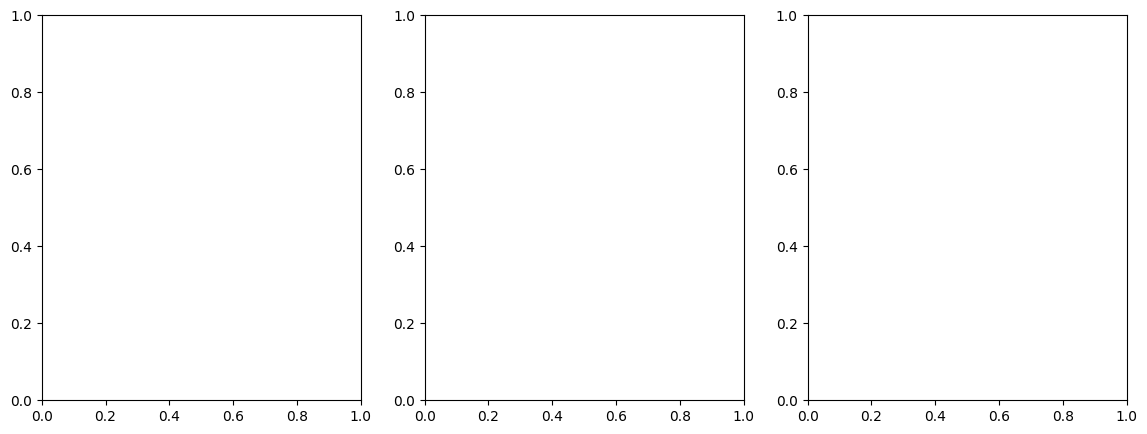

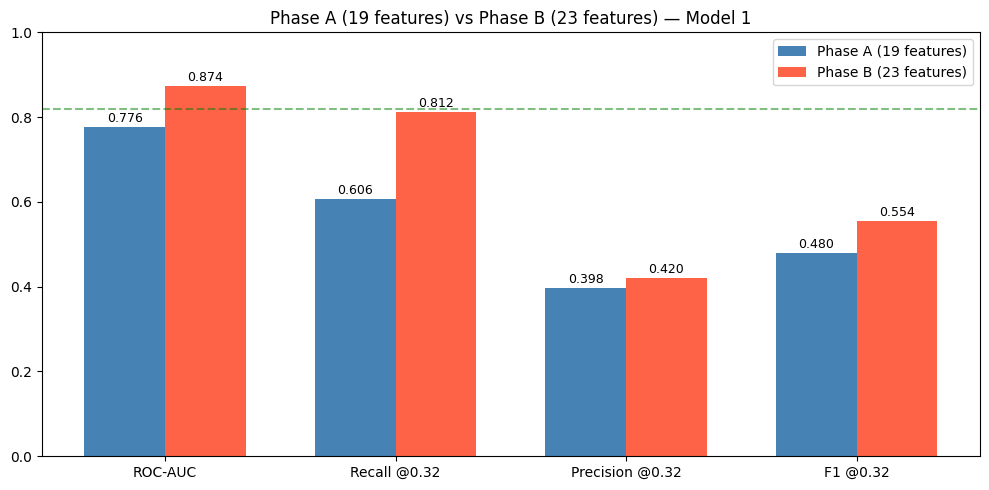


Delta Phase B - Phase A:
  ROC-AUC              +0.0978
  Recall @0.32         +0.2067
  Precision @0.32      +0.0223
  F1 @0.32             +0.0736


In [106]:
from sklearn.metrics import precision_score

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ['ROC-AUC', f'Recall @{THRESHOLD}', f'Precision @{THRESHOLD}', f'F1 @{THRESHOLD}']
phase_a_vals = [
    roc_auc_score(y_a_test, y_pred_a),
    recall_score(y_a_test, (y_pred_a >= THRESHOLD).astype(int)),
    precision_score(y_a_test, (y_pred_a >= THRESHOLD).astype(int), zero_division=0),
    f1_score(y_a_test, (y_pred_a >= THRESHOLD).astype(int)),
]
phase_b_vals = [
    roc_auc_score(y_test, y_pred_proba),
    recall_score(y_test, (y_pred_proba >= THRESHOLD).astype(int)),
    precision_score(y_test, (y_pred_proba >= THRESHOLD).astype(int), zero_division=0),
    f1_score(y_test, (y_pred_proba >= THRESHOLD).astype(int)),
]

for ax, metric, va, vb in zip(
    [axes[0], axes[0], axes[1], axes[2]],
    metrics, phase_a_vals, phase_b_vals
):
    pass  # handled below

x = range(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
bars_a = ax.bar([i - width/2 for i in x], phase_a_vals, width, label='Phase A (19 features)', color='steelblue')
bars_b = ax.bar([i + width/2 for i in x], phase_b_vals, width, label='Phase B (23 features)', color='tomato')

for bar in bars_a:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars_b:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.0)
ax.set_title('Phase A (19 features) vs Phase B (23 features) — Model 1')
ax.legend()
ax.axhline(0.82, color='green', linestyle='--', alpha=0.5, label='Target ROC-AUC')
plt.tight_layout()
plt.show()

print('\nDelta Phase B - Phase A:')
for m, va, vb in zip(metrics, phase_a_vals, phase_b_vals):
    delta = vb - va
    sign = '+' if delta >= 0 else ''
    print(f'  {m:<20} {sign}{delta:.4f}')


---
## 12. Ablation: ¿qué pasa si quitamos `days_since_last_activity`?

El Recall de 0.983 es sospechosamente alto. Probamos quitar el feature más susceptible a leakage.

In [107]:
from src.config import PHASE_B_ALL_FEATURES

# 22 features: Phase B sin days_since_last_activity
FEATURES_NO_DAYS = [f for f in PHASE_B_ALL_FEATURES if f != 'days_since_last_activity']

X_nd = training_df[FEATURES_NO_DAYS].copy()
for col in CAT_FEATURES:
    if col in X_nd.columns:
        X_nd[col] = X_nd[col].astype('category')

X_nd_train, X_nd_test = X_nd[train_mask], X_nd[test_mask]
cat_cols_nd = [c for c in CAT_FEATURES if c in X_nd_train.columns]

model_nd = lgb.LGBMClassifier(**best_params)
model_nd.fit(
    X_nd_train, y_train,
    categorical_feature=cat_cols_nd,
    eval_set=[(X_nd_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
)
y_pred_nd = model_nd.predict_proba(X_nd_test)[:, 1]

THRESHOLD = 0.32
results = pd.DataFrame({
    'Phase A (19 feat)': {
        'ROC-AUC'         : roc_auc_score(y_a_test, y_pred_a),
        'Recall @0.20'    : recall_score(y_a_test, (y_pred_a >= THRESHOLD).astype(int)),
        'Precision @0.20' : precision_score(y_a_test, (y_pred_a >= THRESHOLD).astype(int), zero_division=0),
        'F1 @0.20'        : f1_score(y_a_test, (y_pred_a >= THRESHOLD).astype(int)),
    },
    'Phase B 22 feat\n(sin days)': {
        'ROC-AUC'         : roc_auc_score(y_test, y_pred_nd),
        'Recall @0.20'    : recall_score(y_test, (y_pred_nd >= THRESHOLD).astype(int)),
        'Precision @0.20' : precision_score(y_test, (y_pred_nd >= THRESHOLD).astype(int), zero_division=0),
        'F1 @0.20'        : f1_score(y_test, (y_pred_nd >= THRESHOLD).astype(int)),
    },
    'Phase B 23 feat\n(con days)': {
        'ROC-AUC'         : roc_auc_score(y_test, y_pred_proba),
        'Recall @0.20'    : recall_score(y_test, (y_pred_proba >= THRESHOLD).astype(int)),
        'Precision @0.20' : precision_score(y_test, (y_pred_proba >= THRESHOLD).astype(int), zero_division=0),
        'F1 @0.20'        : f1_score(y_test, (y_pred_proba >= THRESHOLD).astype(int)),
    },
})
print('Ablation test — efecto de days_since_last_activity:')
print(results.round(4).to_string())
print()
if roc_auc_score(y_test, y_pred_nd) > 0.82:
    print('✅ Sin days_since_last_activity: AUC sigue sobre 0.82 — feature no es necesario')
else:
    print('⚠️  Sin days_since_last_activity: AUC baja de 0.82 — feature aporta señal real')

recall_nd = recall_score(y_test, (y_pred_nd >= THRESHOLD).astype(int))
recall_b  = recall_score(y_test, (y_pred_proba >= THRESHOLD).astype(int))
if recall_b - recall_nd > 0.15:
    print(f'🚨 Recall bajó {recall_b - recall_nd:.3f} al quitar days — esa feature tenía señal de leakage')


Ablation test — efecto de days_since_last_activity:
                 Phase A (19 feat)  Phase B 22 feat\n(sin days)  Phase B 23 feat\n(con days)
ROC-AUC                     0.7758                       0.8663                       0.8736
Recall @0.20                0.6057                       0.9762                       0.8124
Precision @0.20             0.3978                       0.3852                       0.4201
F1 @0.20                    0.4802                       0.5524                       0.5538

✅ Sin days_since_last_activity: AUC sigue sobre 0.82 — feature no es necesario


---
## 13. Recalibrar threshold — curva Precision-Recall

Con Phase B el modelo subió los scores. El threshold 0.20 ahora marca ~90% de clientes. Buscamos el punto donde F1 es máximo y donde Recall ≥ 0.75 con mejor Precision.

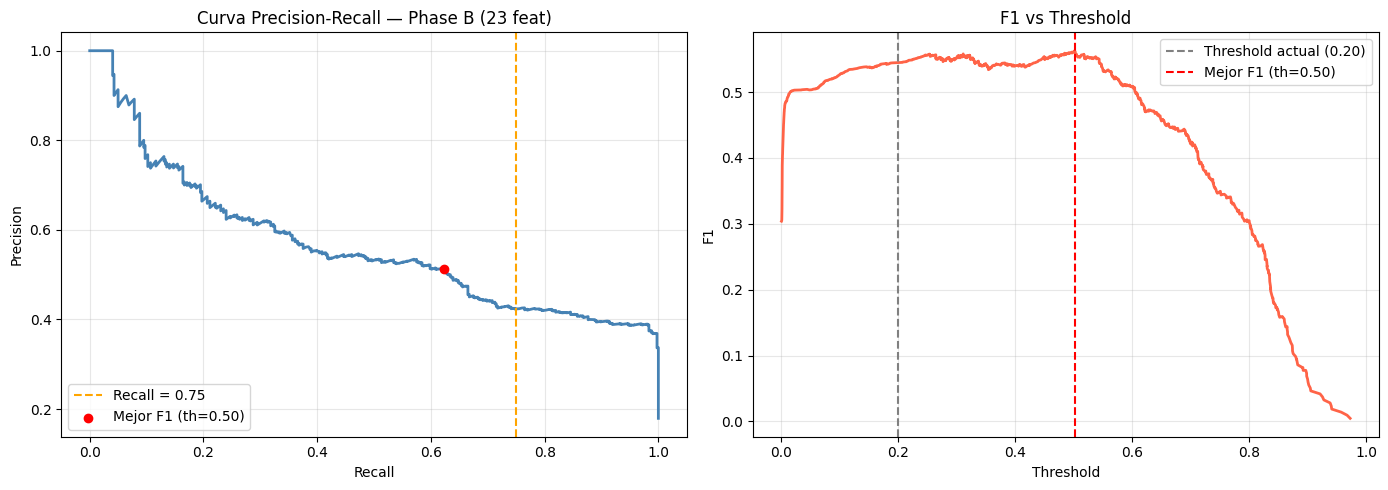

Comparación de thresholds:
   Threshold    Recall   Precision      F1   % flagged
-------------------------------------------------------
        0.20     0.983       0.377   0.545      46.8% ← actual
        0.30     0.876       0.402   0.552      39.0%
        0.40     0.686       0.445   0.540      27.7%
        0.50     0.622       0.512   0.562      21.8% ← mejor F1
        0.34     0.748       0.424   0.541      31.6%


In [108]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_proba)

# F1 por threshold
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

# Threshold donde Recall cae a 0.75 (más selectivo)
recall_75_idx = next((i for i, r in enumerate(recalls) if r <= 0.75), None)
threshold_75  = thresholds[recall_75_idx] if recall_75_idx else None

# Plot
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva P-R
axes[0].plot(recalls, precisions, color='steelblue', lw=2)
axes[0].axvline(0.75, color='orange', linestyle='--', label='Recall = 0.75')
axes[0].scatter(recalls[best_idx], precisions[best_idx], color='red', zorder=5,
                label=f'Mejor F1 (th={best_threshold:.2f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Curva Precision-Recall — Phase B (23 feat)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# F1 vs threshold
axes[1].plot(thresholds, f1_scores[:-1], color='tomato', lw=2)
axes[1].axvline(0.20, color='gray', linestyle='--', label='Threshold actual (0.20)')
axes[1].axvline(best_threshold, color='red', linestyle='--',
                label=f'Mejor F1 (th={best_threshold:.2f})')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F1')
axes[1].set_title('F1 vs Threshold')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Tabla comparativa de thresholds clave
print('Comparación de thresholds:')
print(f'{"Threshold":>12} {"Recall":>9} {"Precision":>11} {"F1":>7} {"% flagged":>11}')
print('-' * 55)
for th in [0.20, 0.30, 0.40, best_threshold, threshold_75 or 0.50]:
    th = round(th, 2)
    preds = (y_pred_proba >= th).astype(int)
    r  = recall_score(y_test, preds)
    p  = precision_score(y_test, preds, zero_division=0)
    f  = f1_score(y_test, preds)
    pct= preds.mean()
    marker = ' ← actual' if th == 0.20 else (' ← mejor F1' if abs(th - best_threshold) < 0.01 else '')
    print(f'{th:>12.2f} {r:>9.3f} {p:>11.3f} {f:>7.3f} {pct:>10.1%}{marker}')
